In [1]:
import sys
import os
import libcontext

In [2]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import time
import math

from torch.optim import Optimizer

In [3]:
def update_uv_with_brand(U, Sigma, V, beta_g, g_bar_col, max_rank):
    # orthogonalizing new columns
    u_residual = beta_g - U @ (U.T @ beta_g)
    v_residual = g_bar_col - V @ (V.T @ g_bar_col)
    
    u_residual_norm = torch.norm(u_residual, p=2)
    v_residual_norm = torch.norm(v_residual, p=2)
    
    if u_residual_norm > 1e-8:
        u_residual = u_residual / u_residual_norm
    else:
        u_residual = torch.zeros_like(u_residual)
    
    if v_residual_norm > 1e-8:
        v_residual = v_residual / v_residual_norm
    else:
        v_residual = torch.zeros_like(v_residual)

    # intermidiate matrix M
    B = torch.cat([U.T @ beta_g, u_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    C = torch.cat([V.T @ g_bar_col, v_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    M = torch.diag(torch.cat([Sigma, torch.zeros(1, device=U.device)])) + B @ C.T  # (r+1, r+1)

    # compute SVD
    U_m, S_m, V_m = torch.linalg.svd(M, full_matrices=False)

    k = min(max_rank, len(S_m)) if max_rank is not None else len(S_m)
    U_m, S_m, V_m = U_m[:, :k], S_m[:k], V_m[:k, :]

    U = torch.cat([U, u_residual], dim=1) @ U_m
    V = torch.cat([V, v_residual], dim=1) @ V_m
    Sigma = S_m
    return U, Sigma, V

In [4]:
from src.adagram import AdaGram
from src.adagram_fixed_rank import AdaGramFR
from src.shampoo import Shampoo
from src.full_matrix import FullMatrixAdaGrad

In [5]:
def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test, 
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True):
    """
    Train a model and evaluate on test data.
    
    Args:
        model: PyTorch model to train
        optimizer: PyTorch optimizer
        criterion: Loss function
        X_train: Training features
        y_train: Training targets
        X_test: Test features
        y_test: Test targets
        num_epochs: Number of training epochs
        opt_name: Name of the optimizer (for logging)
        lr: Learning rate (for logging)
        time_start: Optional start time to calculate average epoch time
        r: Optional rank parameter for logging
        use_tqdm: Whether to use tqdm progress bar
        
    Returns:
        results: List of dictionaries containing training metrics
        test_loss: Final loss on test data
    """

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)
                                                                                                                             
    if time_start is None:
        time_start = time.time()
    
    for epoch in epoch_iterator:
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()

        elapsed_time = time.time() - time_start
        avg_epoch_time = elapsed_time / (epoch + 1)
        
        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()
    
    return results, test_loss


In [6]:
from torch import nn
class LinearRegressionModel(nn.Module):
    def __init__(self, dim_in, dim_out):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(dim_in, dim_out)
    def forward(self, x):
        return self.linear(x)
    
class MultiClassLogisticRegressionModel(nn.Module):
    def __init__(self, num_classes=2, dim=2):
        super(MultiClassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(dim, num_classes)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        return self.softmax(self.linear(x))

In [7]:
import torch
from torch.optim import Optimizer
import math


class AdaGram(Optimizer):
    """Implements the full-matrix version of AdaGrad algorithm using recursive factorization.

    This optimizer adapts the learning rate using the full matrix of outer
    products of gradients, capturing correlations between parameters.

    The implementation uses the recursive formula G_t = L_t L_t^T where L_t
    is updated efficiently at each step without computing the full matrix inverse.

    Args:
        params (iterable): iterable of parameters to optimize
        lr (float, optional): learning rate (default: 1.0)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-10)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        max_rank (int, optional): maximum rank to maintain for U and V matrices (default: None)
    """

    def __init__(self, params, lr=1.0, eps=1e-10, weight_decay=0, max_rank=None):
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps <= 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, eps=eps, weight_decay=weight_decay, max_rank=max_rank)
        super(AdaGram, self).__init__(params, defaults)

    def _compute_alpha(self, g_bar_norm_sq, eps):
        """Compute alpha_t that satisfies the equation (6) in the theorem."""
        # 1 + alpha_t*||g_bar_t||^2 = (1 + ||g_bar_t||^2)^(1/2)
        # for alpha_t:
        # alpha_t = ((1 + ||g_bar_t||^2)^(1/2) - 1) / ||g_bar_t||^2
        return ((1 + g_bar_norm_sq).sqrt() - 1) / (g_bar_norm_sq + eps)

    def _compute_beta(self, alpha, g_bar_norm_sq):
        """Compute beta_t as defined in the theorem."""
        return alpha / (1 + alpha * g_bar_norm_sq)

    def step(self, closure=None):
        """Performs a single optimization step.

        Args:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data

                
                state = self.state[p]

                original_shape = p.data.shape
                grad_vector = grad.reshape(-1)
                param_vector = p.data.reshape(-1)

                # print("orig grad shape", grad.shape)
                # print("grad flat:", grad_vector.shape)
                n = len(grad_vector)

                if len(state) == 0:
                    state["Lt"] = torch.eye(n, device=grad.device, dtype=grad.dtype)
                    state["Lt_inv"] = torch.eye(n, device=grad.device, dtype=grad.dtype)

                if group["weight_decay"] != 0:
                    grad_vector = grad_vector.add(
                        param_vector, alpha=group["weight_decay"]
                    )

                # g_bar = Lt^-1 * g (equation from theorem)
                g_bar = state["Lt_inv"] @ grad_vector
                g_bar_norm_sq = torch.dot(g_bar, g_bar)

                # equation (6)
                alpha = self._compute_alpha(g_bar_norm_sq, eps)

                # equation (7)
                beta = self._compute_beta(alpha, g_bar_norm_sq)

                g_bar_col = g_bar.reshape(-1, 1)  # for outer product calculation

                # equation (5): Lt+1 = Lt(I + alpha * g_bar * g_bar^T)
                outer_product = g_bar_col @ g_bar_col.T
                identity = torch.eye(n, device=grad.device, dtype=grad.dtype)
                state["Lt"] = state["Lt"] @ (identity + alpha * outer_product)

                # equation (7): Lt+1^-1 = (I - beta * g_bar * g_bar^T) * Lt^-1
                state["Lt_inv"] = (identity - beta * outer_product) @ state["Lt_inv"]
                # preconditioned gradient (equation (4))
                precond_grad = g_bar / torch.sqrt(1 + g_bar_norm_sq)

                # Update
                param_vector.add_(precond_grad, alpha=-group["lr"])
                p.data = param_vector.reshape(original_shape)

        return loss


In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.001, 0.01, 0.1]
num_epochs = 140
ranks = [2, 3, 4, 5, 7]
in_dims = [10]
out_dims = [25]

def generate_data(n_samples=100, in_channels=1, out_channels=1, noise=0.1):
    """
    Generate synthetic data for multi-dimensional linear regression.
    
    Args:
        n_samples (int): Number of samples.
        in_channels (int): Input dimension (features per sample).
        out_channels (int): Output dimension (targets per sample).
        noise (float): Magnitude of Gaussian noise added to outputs.
    
    Returns:
        X (torch.Tensor): Input data of shape (n_samples, in_channels).
        y (torch.Tensor): Output data of shape (n_samples, out_channels).
    """
    # Random input data (uniformly distributed in [0, 10])
    X = torch.rand(n_samples, in_channels) * 10
    
    # True weights (slopes) and biases (intercepts)
    true_weights = torch.randn(in_channels, out_channels) * 2  # Random slopes
    true_bias = torch.randn(out_channels) * 1                  # Random biases
    
    # Linear transformation: y = X @ true_weights + true_bias + noise
    y = X @ true_weights + true_bias
    
    # Add Gaussian noise
    y += noise * torch.randn(n_samples, out_channels)
    
    return X, y, true_weights, true_bias


def generate_correlated_data(n_samples=100, in_channels=1, out_channels=1, noise=0.1, correlation_strength=0.7):
    """
    Generate synthetic data with correlated input features.
    
    Args:
        n_samples (int): Number of samples.
        in_channels (int): Input dimension (features per sample).
        out_channels (int): Output dimension (targets per sample).
        noise (float): Magnitude of Gaussian noise added to outputs.
        correlation_strength (float): Correlation between input features (0-1).
    
    Returns:
        X (torch.Tensor): Correlated input data of shape (n_samples, in_channels).
        y (torch.Tensor): Output data of shape (n_samples, out_channels).
    """
    # Create correlation matrix for input features
    correlation_matrix = torch.full((in_channels, in_channels), correlation_strength)
    correlation_matrix.fill_diagonal_(1.0)
    
    # Generate correlated input data using multivariate normal distribution
    mean = torch.zeros(in_channels)
    X_correlated = torch.distributions.MultivariateNormal(mean, correlation_matrix).sample((n_samples,))
    
    # Scale and shift to desired range [0, 10]
    X = (X_correlated - X_correlated.min()) / (X_correlated.max() - X_correlated.min()) * 10
    
    # True weights and biases
    true_weights = torch.randn(in_channels, out_channels) * 2
    true_bias = torch.randn(out_channels) * 1
    
    # Linear transformation with noise
    y = X @ true_weights + true_bias + noise * torch.randn(n_samples, out_channels)
    
    return X, y, true_weights, true_bias



X, y, true_weights, true_bias = generate_data(n_samples=500, in_channels=in_dims[0], out_channels=out_dims[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
optimizers = {
    
    # 'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
    # 'FullMatrixAdaGrad': lambda params, lr: FullMatrixAdaGrad(params, lr=lr),
    # # 'Vanilla SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
    'Torch Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
    'AdaGramFR': lambda params, lr, max_rank: AdaGramFR(params, lr=lr, max_rank=max_rank),
}
models = {}
all_train_losses = {}
all_test_losses = {}
results = []

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
        criterion = nn.MSELoss()
        if opt_name == "AdaGramFR":
            for rank in ranks:
                model = LinearRegressionModel(dim_in=in_dims[0], dim_out=out_dims[0])
                optimizer = opt_fn(model.parameters(), lr, max_rank=rank)
                epoch_results, test_loss = train_model(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                    r=rank
                )
        else:
            model = LinearRegressionModel(dim_in=in_dims[0], dim_out=out_dims[0])
            optimizer = opt_fn(model.parameters(), lr)
            epoch_results, test_loss = train_model(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                )
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.to_csv(f'all_algos_{in_dims[0]}_by_{out_dims[0]}.csv')
# print(f"end {dim}")


 11%|█         | 15/140 [00:00<00:00, 145.69it/s]

rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(6508197.5000)
state['U'].max:  tensor(1.0292e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(1191765.5000)
state['U'].max:  tensor(5.0187e-12)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(7514624.)
state['U'].max:  tensor(1.1884e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(1376056.6250)
state['U'].max:  tensor(5.7955e-12)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(8401134.)
state['U'].max:  tensor(1.3288e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(1538388.2500)
state['U'].max:  tensor(6.4800e-12)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(9202435.)
state['U'].max:  tensor(1.4558e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(1685115.7500)
state['U'].max:  tensor(7.0991e-12)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(9939142.)
state['U'].max:  tensor(1.5726e-13)
rank_U: 

 38%|███▊      | 53/140 [00:00<00:00, 166.98it/s]

tensor(4056799.5000)
state['U'].max:  tensor(1.7236e-11)
rank_U:  tensor(2)
rank_V:  tensor(2)
state['V'].max:  tensor(22466374.)
state['U'].max:  tensor(3.5858e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(4113682.2500)
state['U'].max:  tensor(1.7485e-11)
rank_U:  tensor(2)
rank_V:  tensor(2)
state['V'].max:  tensor(22772574.)
state['U'].max:  tensor(3.6363e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(4169739.5000)
state['U'].max:  tensor(1.7732e-11)
rank_U:  tensor(2)
rank_V:  tensor(2)
state['V'].max:  tensor(23074438.)
state['U'].max:  tensor(3.6863e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(4225003.)
state['U'].max:  tensor(1.7975e-11)
rank_U:  tensor(2)
rank_V:  tensor(2)
state['V'].max:  tensor(23372132.)
state['U'].max:  tensor(3.7356e-13)
rank_U:  tensor(1)
rank_V:  tensor(1)
state['V'].max:  tensor(4279502.)
state['U'].max:  tensor(1.8216e-11)
rank_U:  tensor(2)
rank_V:  tensor(2)
state['V'].max:  tensor(23665

 64%|██████▍   | 90/140 [00:00<00:00, 171.31it/s]

...

tensor(3.0112e-12)
rank_U:  tensor(3)
rank_V:  tensor(3)
state['V'].max:  tensor(4446129.5000)
state['U'].max:  tensor(3.9399e-10)
rank_U:  tensor(4)
rank_V:  tensor(3)
state['V'].max:  tensor(24648952.)
state['U'].max:  tensor(3.0688e-12)
rank_U:  tensor(3)
rank_V:  tensor(3)
state['V'].max:  tensor(4446142.5000)
state['U'].max:  tensor(4.5135e-10)
rank_U:  tensor(4)
rank_V:  tensor(3)
state['V'].max:  tensor(24649684.)
state['U'].max:  tensor(3.1219e-12)
rank_U:  tensor(3)
rank_V:  tensor(3)
state['V'].max:  tensor(4446151.)
state['U'].max:  tensor(5.2217e-10)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24650328.)
state['U'].max:  tensor(3.1706e-12)
rank_U:  tensor(3)
rank_V:  tensor(3)
state['V'].max:  tensor(4446156.5000)
state['U'].max:  tensor(6.1065e-10)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24650898.)
state['U'].max:  tensor(3.2153e-12)
rank_U:  tensor(3)
rank_V:  tensor(3)
state['V'].max:  tensor(4446160.5000)
state['U'].max:  tensor(6

 94%|█████████▍| 132/140 [00:01<00:00, 73.41it/s]

rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24653210.)
state['U'].max:  tensor(3.4148e-12)
rank_U:  tensor(4)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(2.5012e-09)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24653482.)
state['U'].max:  tensor(3.4404e-12)
rank_U:  tensor(4)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(4.1932e-09)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24653740.)
state['U'].max:  tensor(3.5465e-12)
rank_U:  tensor(5)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(5.4771e-09)


100%|██████████| 140/140 [00:01<00:00, 90.85it/s]

rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24653994.)
state['U'].max:  tensor(3.6805e-12)
rank_U:  tensor(5)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(7.2025e-09)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24654248.)
state['U'].max:  tensor(3.8109e-12)
rank_U:  tensor(5)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(1.2764e-08)
rank_U:  tensor(4)
rank_V:  tensor(4)
state['V'].max:  tensor(24654506.)
state['U'].max:  tensor(3.9381e-12)
rank_U:  tensor(5)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(2.5054e-08)
rank_U:  tensor(5)
rank_V:  tensor(4)
state['V'].max:  tensor(24654764.)
state['U'].max:  tensor(4.0620e-12)
rank_U:  tensor(5)
rank_V:  tensor(3)
state['V'].max:  tensor(4446167.)
state['U'].max:  tensor(8.1647e-08)
rank_U:  tensor(5)
rank_V:  tensor(4)
state['V'].max:  tensor(24655018.)
state['U'].max:  tensor(4.1830e-12)
rank_U:  tensor(4)
rank

In [9]:
# df = pd.read_csv(f'all_adagrams_{in_dims[0]}_by_{out_dims[0]}.csv')
df['loss'] = df['loss'].astype(float)
df.head()


,epoch,optimizer,lr,loss,rank,avg_epoch_time
0,0,Torch Adagrad,0.001,1688.932617,NaN,0.005055
1,1,Torch Adagrad,0.001,1686.065186,NaN,0.003525
2,2,Torch Adagrad,0.001,1684.042358,NaN,0.002350
3,3,Torch Adagrad,0.001,1682.393188,NaN,0.002012
4,4,Torch Adagrad,0.001,1680.967041,NaN,0.001809


<Figure size 1500x800 with 0 Axes>

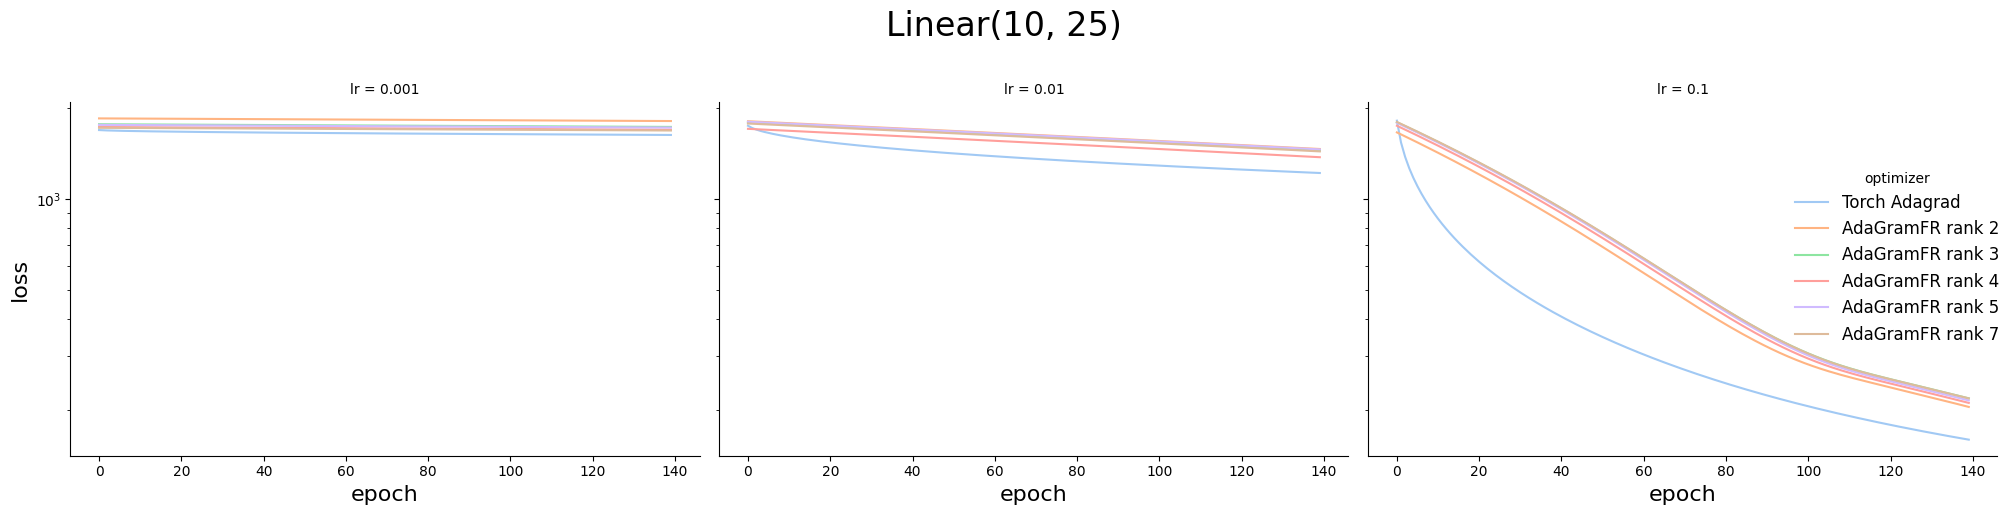

In [10]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df,
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='loss',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='optimizer', title_fontsize='15', fontsize='12')

grid.fig.suptitle(f'Linear({in_dims[0]}, {out_dims[0]})', 
                  fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="lr = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()

In [11]:
df.to_csv('ranks_shampoo_torch.csv', index=False)